## Multi-Model Post-Fire Landslide Probability Workflow

This notebook presents a research-grade, physically based workflow for estimating post-fire landslide susceptibility using Landlab. The analysis starts from preprocessed ESRI ASCII inputs (DEM, soil hydraulic and mechanical properties, vegetation type, and burn severity) generated by the project data pipeline. These layers are loaded onto a common grid and checked for consistency before modeling begins. The core objective is to translate geospatial inputs into process-informed hazard outputs, specifically spatial estimates of landslide probability of failure under observed or scenario meteorological forcing.

The modeling chain links topographic controls (e.g., slope and contributing area), soil state and strength properties (e.g., porosity, field capacity, wilting point, transmissivity, and cohesion), vegetation controls (plant functional type and LAI), and weather forcings (daily precipitation and elevation-adjusted temperature). Radiation and potential evapotranspiration are computed using domain-specific component scripts, then coupled with soil-moisture dynamics to simulate recharge, runoff, and wetness evolution through time. These hydrologic outputs are passed to a stochastic landslide module (`LandslideProbability`) to estimate probability of failure and saturation metrics across the watershed.

This notebook is organized in a stepwise workflow: each code cell is preceded by a short explanation of what is being computed, why that step matters scientifically, and what output to inspect. The final products include maps of `landslide__probability_of_failure`, `soil__probability_of_saturation`, and `soil__mean_relative_wetness`, along with time-series diagnostics of recharge and runoff. The structure is intended to support reproducible post-fire hazard assessment and rapid adaptation for new events in research.


### Step 1: Import Libraries and Components
Load plotting, numerical, and Landlab modules, including custom PET, radiation, and soil-moisture components used later in the workflow.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

from landlab.components import SinkFillerBarnes, FlowAccumulator, DepressionFinderAndRouter, FlowDirectorMFD
from landlab.io import esri_ascii
from landlab.plot.imshow import imshow_grid
from landlab.plot.imshow import imshow_grid_at_node, imshow_grid_at_cell
from matplotlib.colors import ListedColormap

from landlab.components.landslides import LandslideProbability
#from landlab.components.mass_wasting_router.landslide_mapper import LandslideMapper as LM
from landlab.components.mass_wasting_runout import MassWastingRunout
from landlab.grid.mappers import map_node_to_cell
from potential_evapotranspiration_field_OFFICIAL import PotentialEvapotranspiration  
from radiation_field_OFFICIAL import Radiation 
from soil_moisture_dynamics import SoilMoisture
from recharge_routing import route_recharge_field


### Step 2: Load DEM and Initialize Grid
Set the working data directory, load the DEM ASCII into a Landlab grid, set nodata/boundary conditions, and identify outlet and elevation bounds.


In [3]:
# with open("Stehekin_10m.asc") as f:
#     grid = esri_ascii.load(f, name="topographic__elevation")

# Z = grid.at_node["topographic__elevation"]

# grid.set_nodata_nodes_to_closed(Z, -999999)

# # find the lowest point on our DEM?
# outlet_id = grid.core_nodes[np.argmin(grid.at_node['topographic__elevation'][grid.core_nodes])]

# # set the lowest point as the outlet, make all the nodes above this point core nodes
# grid.set_watershed_boundary_condition_outlet_id(outlet_id, Z)

# Zmin=np.min(grid.at_node['topographic__elevation'][grid.core_nodes])  #let's find the lowest point to scale our lapse rate
# Zmax=np.max(grid.at_node['topographic__elevation'][grid.core_nodes])  # maximum elevation

# print("Outlet ID=", outlet_id)                                        # print outlet id number
# print("Outlet elevation=",grid.at_node['topographic__elevation'][outlet_id])        # print elevation of outlet node
# print("Min elevation of core nodes=", Zmin) # print minimum elevation of core nodes
# print("Max elevation of core nodes=", Zmax) # print maximum elevation of core nodes




from pathlib import Path
from landlab.io import esri_ascii
import numpy as np

os.chdir("/home/abdullah/fire-debrisflow-ml/data")

asc_dir = Path("/home/abdullah/fire-debrisflow-ml/data")
dem_path = asc_dir / "topographic__elevation.asc" 

with dem_path.open() as f:
    grid = esri_ascii.load(f, name="topographic__elevation")

Z = grid.at_node["topographic__elevation"]
grid.set_nodata_nodes_to_closed(Z, -999999)

outlet_id = grid.core_nodes[np.argmin(grid.at_node["topographic__elevation"][grid.core_nodes])]
grid.set_watershed_boundary_condition_outlet_id(outlet_id, Z)

Zmin = np.min(grid.at_node["topographic__elevation"][grid.core_nodes])
Zmax = np.max(grid.at_node["topographic__elevation"][grid.core_nodes])

print("Outlet ID=", outlet_id)
print("Outlet elevation=", grid.at_node["topographic__elevation"][outlet_id])
print("Min elevation of core nodes=", Zmin)
print("Max elevation of core nodes=", Zmax)

Outlet ID= 3158
Outlet elevation= 328.21478
Min elevation of core nodes= 328.7414
Max elevation of core nodes= 1808.6389


### Step 3: Check Grid Geometry
Print node counts, core-node counts, and grid spacing so you can verify domain size before running routing and stability calculations.


In [4]:
print('Number of nodes=', grid.number_of_nodes)
print('Number of core nodes=', grid.number_of_core_nodes)

cell_width=grid.dx
cell_width

print('Area_of_core_nodes km2=', grid.number_of_core_nodes*grid.dx*grid.dy/1000000)

Number of nodes= 513500
Number of core nodes= 176194
Area_of_core_nodes km2= 17.6194


### Step 4: Visualize Elevation
Plot `topographic__elevation` to confirm terrain quality, extent, and unit consistency before derivative computations.


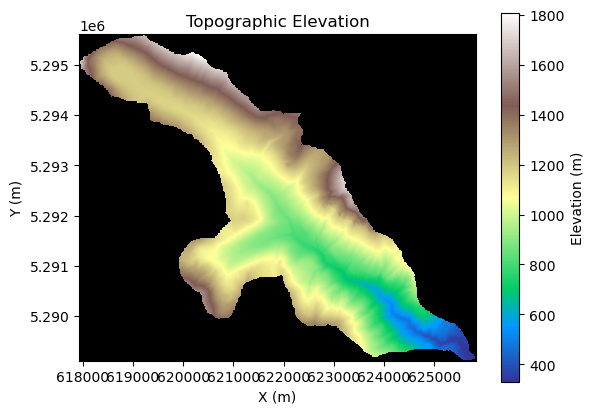

In [5]:
imshow_grid(grid,'topographic__elevation', plot_name = 'Topographic Elevation',
            var_name = 'Elevation', var_units = 'm', grid_units = ('m','m'),
            cmap = 'terrain')
plt.show()

### Step 5: Run Flow Routing Preprocessing
Fill sinks and run flow accumulation so drainage area and flow-direction dependent metrics are physically consistent.


In [6]:
# Fill sinks to see if Flow Accumulator works better, this needs an outlet ID. if depression finder and router is used this step can be skipped, as long as the outlet drainge area is consisten with the area calculated above
sfb = SinkFillerBarnes(grid,'topographic__elevation', method='D8', fill_flat = False,
                      ignore_overfill = False)
sfb.run_one_step()

fa = FlowAccumulator(grid,
                     surface='topographic__elevation',
                     flow_director='FlowDirectorD8',
                     runoff_rate=None,
                     #depression_finder='DepressionFinderAndRouter'
                    )

(da, q) = fa.accumulate_flow()

/home/abdullah/miniconda3/envs/landlab_debrisflow/lib/python3.11/site-packages/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


### Step 6: Derive Terrain Attributes
Create and inspect slope/aspect/hillshade fields; these terrain controls are central to runoff concentration and slope instability.


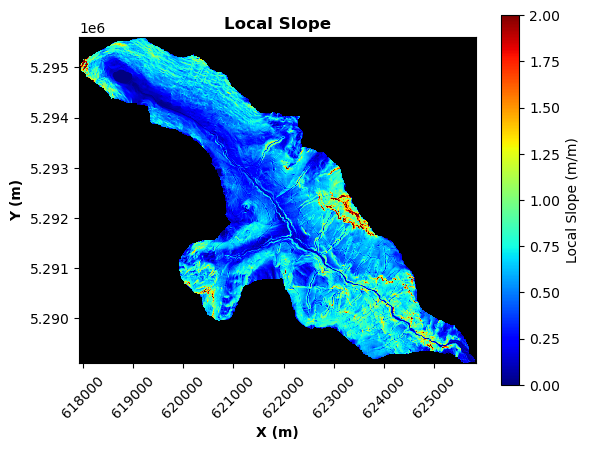

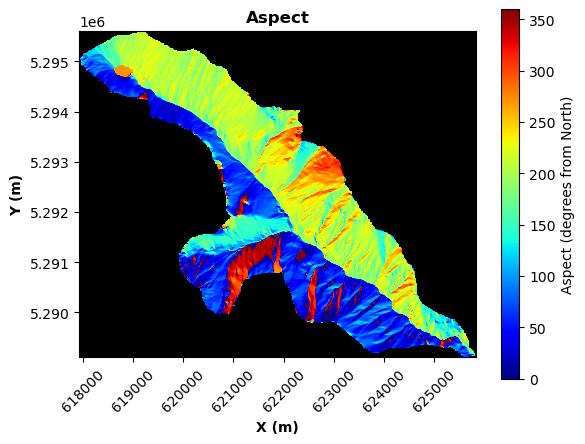

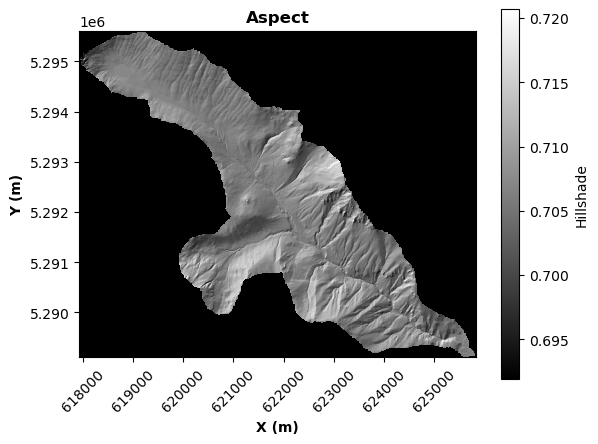

In [7]:
#Plotting slope, aspect, and hillshade
grid.add_field('topographic__slope', grid.at_node['topographic__steepest_slope'], at='node', clobber=True) ## used by the landslide model

imshow_grid(grid,'topographic__steepest_slope', plot_name = 'Local Slope',
            var_name = 'Local Slope', var_units = 'm/m', grid_units = ('m','m'),
            cmap = 'jet', limits=(0,2))
plt.title('Local Slope', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()


aspect=grid.calc_aspect_at_node(elevs=Z)
slope=grid.calc_slope_at_node(elevs=Z)
hillshade=grid.calc_hillshade_at_node(elevs=Z, alt=45, az=315, slp=slope, asp=aspect)

_=grid.add_field('Aspect', aspect, at='node', clobber=True)
_=grid.add_field('Hillshade', hillshade, at='node', clobber=True)

#Aspect
imshow_grid(grid,'Aspect', plot_name = 'Aspect',
            var_name = 'Aspect', var_units = 'degrees from North', grid_units = ('m','m'),
            cmap = 'jet', limits=(0,360))
plt.title('Aspect', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

#Hillshade
imshow_grid(grid,'Hillshade', plot_name = 'Aspect',
            var_name = 'Hillshade', grid_units = ('m','m'),
            cmap = 'gray')
plt.title('Aspect', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### Step 7: Compute Specific Contributing Area
Convert drainage area to specific contributing area (`topographic__specific_contributing_area`) for hydrologic response analysis.


In [8]:
cell_width=grid.dx

ca=grid.at_node['drainage_area']/cell_width  # now calculate SCA

_=grid.add_field('topographic__specific_contributing_area', ca, at='node', clobber=True)

### Step 8: Load Soil Thickness
Import `soil__thickness` from ASCII, attach it to the grid, set nodata handling, and quickly inspect spatial patterns.


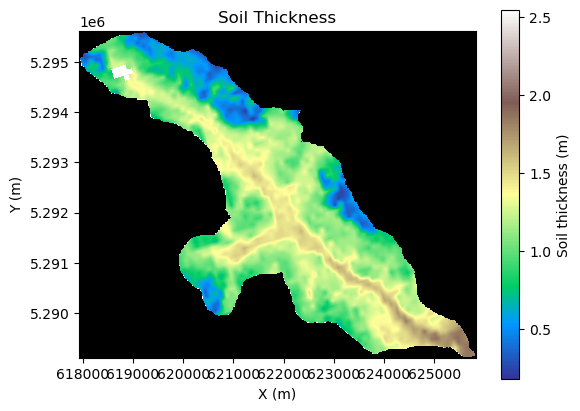

In [9]:
# Soil Thickness data from SOLIS

with open("soil__thickness.asc") as f:
    hs_grid = esri_ascii.load(f, name="soil__thickness")

hs = hs_grid.at_node["soil__thickness"]

_=grid.add_field('soil__thickness', hs, at='node', clobber=True)   #SOLS data in cmm # investigate this

grid.set_nodata_nodes_to_closed(hs, 2.549999999999999822e+00)

imshow_grid(grid,'soil__thickness', plot_name = 'Soil Thickness',
            var_name = 'Soil thickness', var_units = 'm', grid_units = ('m','m'),
            cmap = 'terrain')

### Step 9: Load Soil Density
Import `soil__density`, add it to the grid, close nodata nodes, and verify distribution with a map.


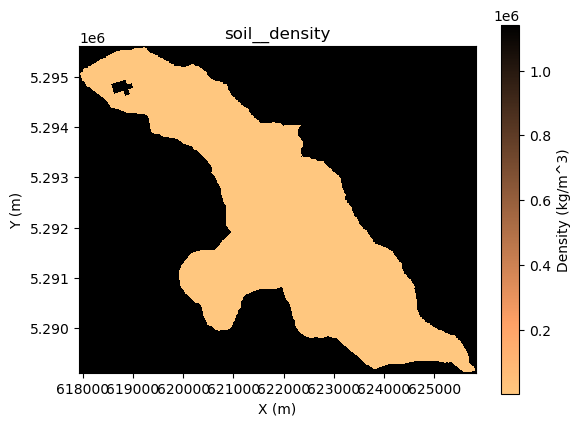

In [10]:
#Soil density data

with open("soil__density.asc") as f:
    ro_grid = esri_ascii.load(f, name="soil__density")

ro = ro_grid.at_node["soil__density"]

_=grid.add_field('soil__density', ro, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(ro, 4.259999999999999898e-01)

imshow_grid_at_node(grid,'soil__density', plot_name = 'Soil Density',
            var_name = 'Density', var_units = 'kg/m^3', grid_units = ('m','m'),
            cmap = 'copper_r')

### Step 10: Load Internal Friction Angle
Import `soil__internal_friction_angle` and register it as a node field for the landslide stability component.


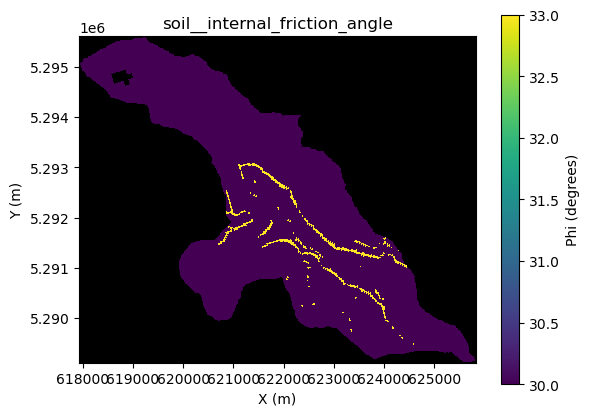

In [11]:
#Soil Internal friction angle from soil texture classification and look-up values from XX

with open("soil__internal_friction_angle.asc") as f:
    phi_grid = esri_ascii.load(f, name="soil__internal_friction_angle")

phi = phi_grid.at_node["soil__internal_friction_angle"]

_=grid.add_field('soil__internal_friction_angle', phi, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(phi, 2.700000000000000000e+01)

imshow_grid_at_node(grid,'soil__internal_friction_angle', plot_name = 'Friction angle',
           var_name = 'Phi', var_units = 'degrees', grid_units = ('m','m'),
           cmap = 'viridis')

### Step 11: Load Soil Hydraulic Properties
Import porosity, field capacity, wilting point, and saturated hydraulic conductivity, then add each as grid fields.


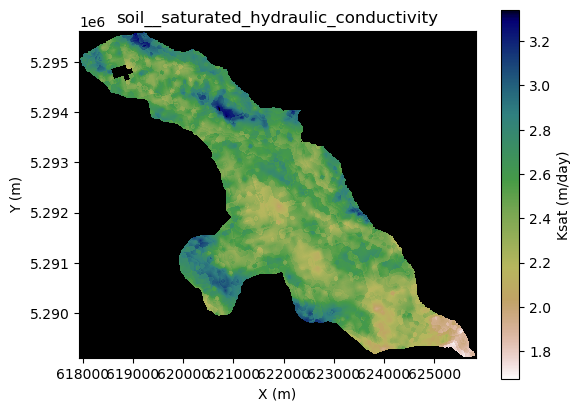

In [12]:
## Porosity

with open("porosity.asc") as f:
    n_grid = esri_ascii.load(f, name="porosity")

n = n_grid.at_node["porosity"]

_=grid.add_field('porosity', n, at='node', clobber=True)


## Field Capacity

with open("field__capacity.asc") as f:
    fc_grid = esri_ascii.load(f, name="field__capacity")

fc = fc_grid.at_node["field__capacity"]

_=grid.add_field('field__capacity', fc, at='node', clobber=True)


## Wilting Point

with open("wilting__point.asc") as f:
    wp_grid = esri_ascii.load(f, name="wilting__point")

wp = wp_grid.at_node["wilting__point"]

_=grid.add_field('wilting__point', wp, at='node', clobber=True)



## Saturated Hydraulic Conductivity

with open("soil__saturated_hydraulic_conductivity.asc") as f:
    ksat_grid = esri_ascii.load(f, name="soil__saturated_hydraulic_conductivity")

ksat = ksat_grid.at_node["soil__saturated_hydraulic_conductivity"]

_=grid.add_field('soil__saturated_hydraulic_conductivity', ksat, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(ksat, 7.052563416309979523e+93)

imshow_grid_at_node(grid,'soil__saturated_hydraulic_conductivity', plot_name = 'Ksat',
            var_name = 'Ksat', var_units = 'm/day', grid_units = ('m','m'),
            cmap = 'gist_earth_r')

### Step 12: Compute Transmissivity
Derive `soil__transmissivity` from conductivity and thickness, enforce a small positive floor, and map the result.


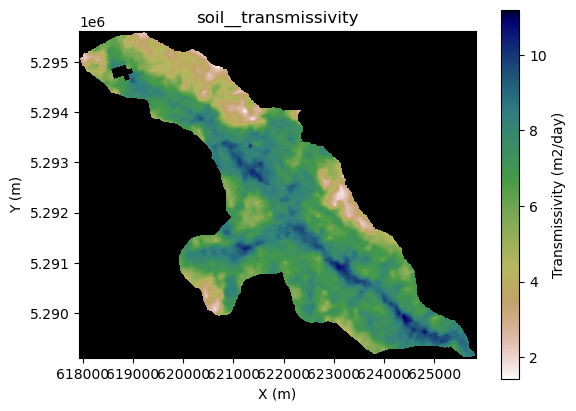

In [13]:
To=ksat*2.5*(hs) #m^2/day #To=ksat*2.5*(hs/100), anisotropic ratio- 
for i in range(len(To)):
    if To[i] <= 0:
        To[i] = 0.01

_=grid.add_field('soil__transmissivity', To, at='node',clobber=True)

imshow_grid_at_node(grid,'soil__transmissivity', plot_name = 'Transmissivity',
            var_name = 'Transmissivity', var_units = 'm2/day', grid_units = ('m','m'),
            cmap = 'gist_earth_r')

### Step 13: Load Vegetation Functional Type
Import `vegetation__plant_functional_type`, cast to integer categories, and visualize the classified vegetation map.


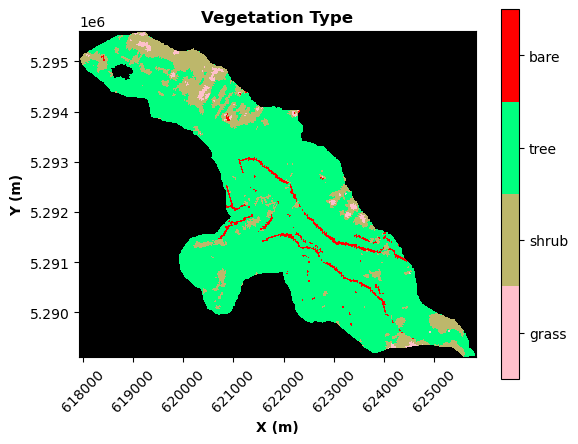

In [14]:
with open("vegetation__plant_functional_type.asc") as f:
    vt_grid = esri_ascii.load(f, name="vegetation__plant_functional_type")

vt = vt_grid.at_node["vegetation__plant_functional_type"]

_=grid.add_field('vegetation__plant_functional_type', vt, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(vt, -9.999000000000000000e+03)

grid.add_field('vegetation__plant_functional_type', vt.astype(int), at='node', clobber=True)
imshow_grid_at_node(grid, 'vegetation__plant_functional_type', plot_name = 'Vegetation Type',
            cmap = ListedColormap(['pink',"darkkhaki", "springgreen", "red"], N=4), limits = (-0.5,3.5), allow_colorbar= False)
cb = plt.colorbar()
cb.set_ticks([0,1,2,3])
cb.set_ticklabels(['grass', 'shrub','tree','bare'])
plt.title('Vegetation Type', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### Step 14: Map Vegetation to Cells
Convert vegetation type from nodes to cells so ecohydrologic processes operating on cells receive the correct inputs.


In [15]:
# Map PFT from node to cell as the ecohydrology model operates on cells
grid['cell']['vegetation__plant_functional_type']=map_node_to_cell(grid, "vegetation__plant_functional_type").astype(int)
for i in range(len(grid['cell']['vegetation__plant_functional_type'])):
        if grid['cell']['vegetation__plant_functional_type'][i] < 0:
            grid['cell']['vegetation__plant_functional_type'][i] = 0

### Step 15: Create Leaf Area Index Field
Assign LAI values by plant functional type and store `vegetation__live_leaf_area_index` for ecohydrology and ET calculations.


In [16]:
LAI_grass = 1.5
LAI_shrub = 2.0
LAI_tree  = 4.0

## create or replace the field
grid.add_field('vegetation__live_leaf_area_index',
               np.zeros(grid.number_of_nodes, dtype=float),
               at='node', clobber=True)

pft = grid.at_node['vegetation__plant_functional_type']
lai = grid.at_node['vegetation__live_leaf_area_index']  # we can pass this directly

for i in range(grid.number_of_nodes):
    if pft[i] == 0:
        lai[i] = LAI_grass
    elif pft[i] == 1:
        lai[i] = LAI_shrub
    elif pft[i] == 2:
        lai[i] = LAI_tree
    elif pft[i] == 3:
        lai[i] = 1   ## default for bare

grid['cell']['vegetation__live_leaf_area_index']=map_node_to_cell(grid, "vegetation__live_leaf_area_index")

### Step 16: Inspect LAI
Plot LAI at cell scale as a quality-control step before forcing the water balance model.


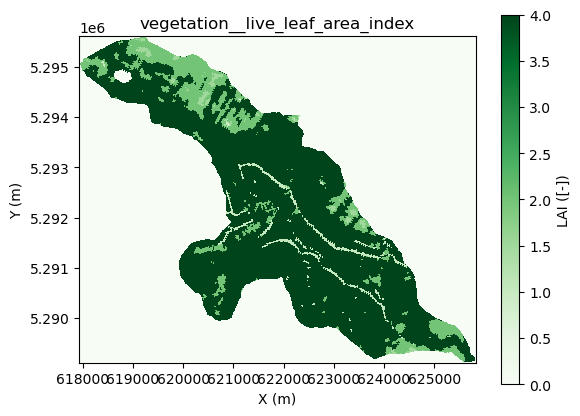

In [17]:
imshow_grid_at_cell(grid,'vegetation__live_leaf_area_index', plot_name = 'LAI',
            var_name = 'LAI', var_units = '[-]', grid_units = ('m','m'),
            cmap = 'Greens')

### Step 17: Load Cohesion Surfaces
Import minimum, mode, and maximum root/soil cohesion fields from ASC inputs and attach them to the grid.


In [18]:
with open("soil__maximum_total_cohesion.asc") as f:
    cmax_grid = esri_ascii.load(f, name="soil__maximum_total_cohesion")

cmax = cmax_grid.at_node["soil__maximum_total_cohesion"] 

_=grid.add_field('soil__maximum_total_cohesion', cmax, at='node', clobber=True)


with open("soil__mode_total_cohesion.asc") as f:
    cmode_grid = esri_ascii.load(f, name="soil__mode_total_cohesion")

cmode = cmode_grid.at_node["soil__mode_total_cohesion"]

_=grid.add_field('soil__mode_total_cohesion', cmode, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(cmode, -9.999000000000000000e+03)


with open("soil__minimum_total_cohesion.asc") as f:
    cmin_grid = esri_ascii.load(f, name="soil__minimum_total_cohesion")

cmin = cmin_grid.at_node["soil__minimum_total_cohesion"]

_=grid.add_field('soil__minimum_total_cohesion', cmin, at='node', clobber=True)

grid.set_nodata_nodes_to_closed(cmax, -9.999000000000000000e+03)

#imshow_grid_at_node(grid,'soil__minimum_total_cohesion_pre', plot_name = 'Minimum cohesion',
#            var_name = 'Soil Cohesion', var_units = 'Pa', grid_units = ('m','m'),
#            cmap = 'Greens')

#imshow_grid_at_node(grid,'soil__maximum_total_cohesion_pre', plot_name = 'Maximum cohesion',
#            var_name = 'Soil Cohesion', var_units = 'Pa', grid_units = ('m','m'),
#            cmap = 'Greens')

#imshow_grid_at_node(grid,'soil__mode_total_cohesion_pre', plot_name = 'Mode cohesion',
#            var_name = 'Soil Cohesion', var_units = 'Pa', grid_units = ('m','m'), cmap = 'Greens')

#grid.add_field('soil__mode_total_cohesion', C_mode, at='node',clobber=True)  to BE DELETED
#grid.add_field('soil__minimum_total_cohesion', C_min, at='node',clobber=True)
#grid.add_field('soil__maximum_total_cohesion', C_max, at='node', clobber=True)

In [19]:
# Descriptive stats

fields = [
    "soil__minimum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__maximum_total_cohesion",
]

rows = []
for f in fields:
    a = np.asarray(grid.at_node[f], dtype=float)[grid.core_nodes]
    a = a[np.isfinite(a)]
    rows.append({
        "field": f,
        "count": a.size,
        "min": np.min(a),
        "p25": np.percentile(a, 25),
        "mean": np.mean(a),
        "median": np.median(a),
        "p75": np.percentile(a, 75),
        "max": np.max(a),
        "std": np.std(a, ddof=1) if a.size > 1 else np.nan,
    })

pd.DataFrame(rows).set_index("field")

NameError: name 'pd' is not defined

In [21]:
from pathlib import Path
from landlab.io import esri_ascii

control_factor = 0.5
suffix = "neg50p"
out_dir = Path("/home/abdullah/fire-debrisflow-ml/data/sensitivity")
out_dir.mkdir(parents=True, exist_ok=True)

base_fields = [
    "soil__maximum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__minimum_total_cohesion",
]

for base in base_fields:
    new_name = f"{base}_{suffix}"

    vals = grid.at_node[base].copy()
    vals_mod = vals.copy()
    vals_mod[grid.core_nodes] = vals[grid.core_nodes] * control_factor

    grid.add_field(new_name, vals_mod, at="node", clobber=True)

    out_path = out_dir / f"{new_name}.asc"
    with open(out_path, "w") as f:
        esri_ascii.dump(grid, f, at="node", name=new_name)

print("Saved:")
for b in base_fields:
    print(out_dir / f"{b}_{suffix}.asc")

Saved:
/home/abdullah/fire-debrisflow-ml/data/sensitivity/soil__maximum_total_cohesion_neg50p.asc
/home/abdullah/fire-debrisflow-ml/data/sensitivity/soil__mode_total_cohesion_neg50p.asc
/home/abdullah/fire-debrisflow-ml/data/sensitivity/soil__minimum_total_cohesion_neg50p.asc


### Step 18: Load Burn Severity
Import `burn__severity` as a spatial forcing layer used to condition post-fire hydrologic and slope-failure behavior.


In [22]:
with open("burn__severity.asc") as f:
    bs_grid = esri_ascii.load(f, name="burn__severity")

bs = bs_grid.at_node["burn__severity"]

_=grid.add_field('burn__severity', bs, at='node', clobber=True)

### Step 19: Reclassify Burn Severity
Normalize burn classes so non-target categories are set to baseline class 1 for consistent model treatment.


In [23]:
bs[~np.isin(bs, [2, 3, 4])] = 1

### Step 20: Inspect Burn Severity Map
Plot burn severity classes and legend labels to confirm expected fire footprint and class encoding.


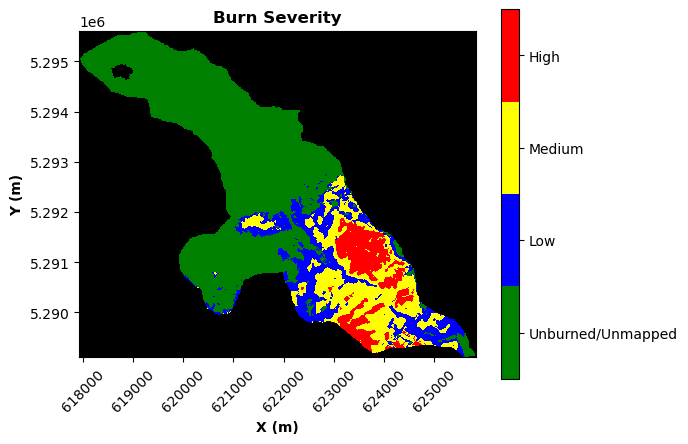

In [24]:
imshow_grid_at_node(grid, 'burn__severity', plot_name = 'Burn Severity',
            cmap = ListedColormap(['green',"blue", "yellow", "red"], N=4), limits = (0.5,4.5), allow_colorbar= False)
cb = plt.colorbar()
cb.set_ticks([1,2,3,4])
cb.set_ticklabels(['Unburned/Unmapped', 'Low','Medium','High'])
plt.title('Burn Severity', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()
plt.show()

In [ ]:
# suffix = "burnsevRed"
# out_dir = Path("/home/abdullah/fire-debrisflow-ml/data/sensitivity")
# out_dir.mkdir(parents=True, exist_ok=True)

# base_fields = [
#     "soil__maximum_total_cohesion",
#     "soil__mode_total_cohesion",
#     "soil__minimum_total_cohesion",
# ]

# # Burn class -> reduction fraction
# reduction = {
#     1: 0.00,  # Unburned
#     2: 0.15,  # Low
#     3: 0.35,  # Medium
#     4: 0.60,  # High
# }

# burn = grid.at_node["burn__severity"].astype(int)

# # Node-wise multiplier (default = no reduction)
# mult = np.ones(grid.number_of_nodes, dtype=float)
# for cls, red in reduction.items():
#     mult[burn == cls] = 1.0 - red

# # Optional: apply only on core nodes (uncomment if needed)
# # core_mask = np.zeros(grid.number_of_nodes, dtype=bool)
# # core_mask[grid.core_nodes] = True
# # mult = np.where(core_mask, mult, 1.0)

# for base in base_fields:
#     new_name = f"{base}_{suffix}"
#     vals_mod = grid.at_node[base].copy() * mult

#     grid.add_field(new_name, vals_mod, at="node", clobber=True)

#     out_path = out_dir / f"{new_name}.asc"
#     with open(out_path, "w") as f:
#         esri_ascii.dump(grid, f, at="node", name=new_name)

# print("Saved:")
# for b in base_fields:
#     print(out_dir / f"{b}_{suffix}.asc")

### Step 21: Set Initial Soil Saturation
Compute `soil_moisture__initial_saturation_fraction` from field capacity, wilting point, and porosity, then map node-to-cell.


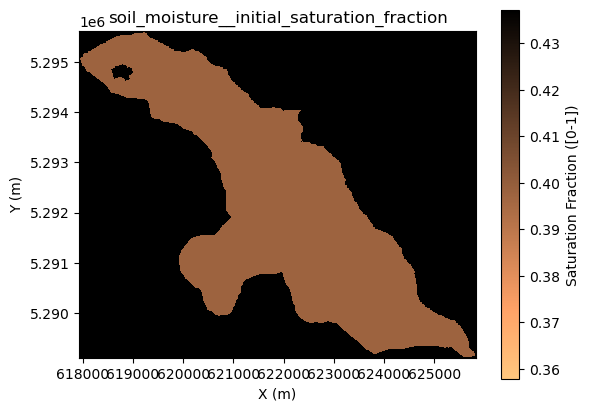

In [25]:
Saturation_fraction=(0.5*(grid.at_node['field__capacity']-grid.at_node['wilting__point'])+grid.at_node['wilting__point'])/grid.at_node['porosity']

_=grid.add_field('soil_moisture__initial_saturation_fraction', Saturation_fraction, at='node', clobber=True)

grid['cell']['soil_moisture__initial_saturation_fraction']=map_node_to_cell(grid, "soil_moisture__initial_saturation_fraction")

imshow_grid_at_node(grid,'soil_moisture__initial_saturation_fraction', plot_name = 'Saturation fraction',
            var_name = 'Saturation Fraction', var_units = '[0-1]', grid_units = ('m','m'),
            cmap = 'copper_r')

### Step 22: Set PET/Radiation Site Constants
Define fixed site parameters (latitude and albedo) used by radiation and potential evapotranspiration calculations.


In [26]:
Latitude=47.7
Albedo=0.2

### Step 23: Set Meteorological Constants
Define canopy height, wind reference height, wind speed, and relative humidity for PET/energy-balance calculations.


In [27]:
Zveg=0.5 # vegetation height [m] 
Z_wind=2.0 # height at which wind speed was recorded. This should be above the canopy height
Vwind=3.04 # wind speed m/s
Relative_humidity=0.8 # relative humidity

### Step 24: Build Daily Forcing Series
Create elevation-adjusted daily Tmin/Tmax and precipitation forcing arrays using lapse-rate corrections and observed station data.


In [28]:
alpha = 4.5      # °C/km lapse rate
Zref = Zmin     # m, station elevation

# Observed values (lists)
Tmin_o = [
 -0.61, 4.89, 4.78, 2.28, -0.72, -2.22, -1.50, 2.22, 0.22, 0.22,
  0.00, 2.89, 0.22, -0.72, 0.22, 0.44, 0.89, 0.28, 1.11, 1.28,
  1.28, 1.50, 0.28, 4.61, 4.72, 3.89, 6.72, 5.50, 2.72, -0.28, 4.61
] #C

Tmax_o = [
 17.72, 10.50, 8.50, 9.11, 10.61, 8.39, 12.61, 12.61, 14.50, 6.72,
 9.28, 9.22, 6.50, 6.72, 5.00, 5.50, 6.28, 8.22, 9.89, 6.22,
 5.72, 9.00, 4.80, 8.89, 19.50, 22.50, 14.61, 9.39, 13.39, 14.61, 9.61
] #C

P_obs  = [0.0, 0.0, 2.03, 7.62, 2.8, 0.0, 0.0, 0.0, 15.5, 11.43, 1.8, 14.2,
          21.1, 2.3, 28.5, 10.7, 14.5, 2.03, 1.01, 26.67, 47.24, 10.4, 120,
          42.2, 0.0, 12.2, 20.6, 14.7, 2.03, 0, 4.8] # mm

rainfall_arrays = []
tempmin_arrays = []
tempmax_arrays = []

for tmin_ref, tmax_ref, P_ref in zip(Tmin_o, Tmax_o, P_obs):

    Tmax = tmax_ref - alpha * ((Z - Zref) / 1000.0)
    Tmin = tmin_ref - alpha * ((Z - Zref) / 1000.0)
    Ta   = ((tmin_ref + tmax_ref) / 2.0) - alpha * ((Z - Zref) / 1000.0)  ### zref is where temp measured. 

    P_grid = np.full_like(Z, P_ref, dtype=float)

    # store each day's fields
    rainfall_arrays.append(P_grid)
    tempmin_arrays.append(Tmin)
    tempmax_arrays.append(Tmax)

### Step 25: Run Daily Hydro-Eco Simulation
For each day, apply rainfall/temperature forcings, run Radiation + PET + SoilMoisture components, and store runoff/recharge/soil-moisture/ET outputs.


In [29]:
t = 2
runoff_arrays=[]
recharge_arrays=[]
soil_moisture_arrays=[]
ET_arrays=[]
mask = np.isin(grid.at_node['burn__severity'], [2, 3, 4]) & np.isin(np.arange(grid.number_of_nodes), grid.core_nodes)

current_time=0.22
Vt=grid.at_node['vegetation__live_leaf_area_index']/4
_=grid.add_field('vegetation__cover_fraction', Vt , at='node',clobber=True)
grid['cell']['vegetation__cover_fraction']=map_node_to_cell(grid, "vegetation__cover_fraction")

for idx, (rainfall, tempmin, tempmax) in enumerate(zip(rainfall_arrays, tempmin_arrays, tempmax_arrays)):
    # Take each day's data from the above data zip

    _=grid.add_field('Precipitation', rainfall, at='node',clobber=True) #m^2/day
    grid.set_nodata_nodes_to_closed(rainfall, -9999.)

    _=grid.add_field('Tmin', tempmin , at='node',clobber=True)
    grid.set_nodata_nodes_to_closed(tempmin, -9999.)

    _=grid.add_field('Tmax', tempmax , at='node',clobber=True)
    grid.set_nodata_nodes_to_closed(tempmax, -9999.)

    # THIS IS DONE TO PASS "P" TO THE COMPONENT..?
    grid['cell']['Precipitation']=map_node_to_cell(grid, "Precipitation")
    P=grid['cell']['Precipitation']
    grid['cell']['rainfall__daily_depth'] = P
   ## Soil_Saturation=grid['cell']['soil_moisture__initial_saturation_fraction'] ERKANI--DO YOU NEED THIS

    grid['cell']['saturated__hydraulic_conductivity']=map_node_to_cell(grid, "soil__saturated_hydraulic_conductivity")
    #ksat_t_cell=grid['cell']['saturated__hydraulic_conductivity']

    #grid['cell']['saturated__hydraulic_conductivity_pre']=map_node_to_cell(grid, "soil__saturated_hydraulic_conductivity_pre")
    #ksat_cell=grid['cell']['saturated__hydraulic_conductivity_pre']

    grid['cell']['live_leaf_area_index']=map_node_to_cell(grid,"vegetation__live_leaf_area_index")
    #lai_t_cell=grid['cell']['live_leaf_area_index']

    #grid['cell']['live_leaf_area_index_pre']=map_node_to_cell(grid, "vegetation__live_leaf_area_index_pre")
    #lai_cell=grid['cell']['live_leaf_area_index_pre']

    grid['cell']['Porosity']=map_node_to_cell(grid, "porosity")  # used for calculating soil saturation
    Porosity=grid['cell']['Porosity']



    # Radiation and PET modeling
    myTmin = grid.at_node["Tmin"]
    myTmax = grid.at_node["Tmax"]

    rad = Radiation(grid, method='Grid')
    PET=PotentialEvapotranspiration(grid, method='PenmanMonteith')
    SM = SoilMoisture(grid)

    rad._current_time=current_time
    rad._latitude=Latitude
    rad._A=Albedo
    rad._Tmin = myTmin
    rad._Tmax = myTmax
    rad.update()

    PET._current_time=current_time
    PET._latitude=Latitude
    PET._a=Albedo
    PET._Tmin= myTmin
    PET._Tmax= myTmax
    PET._zm = Z_wind
    PET._zveg = Zveg * np.ones(grid.number_of_cells)
    PET._vz = Vwind * np.ones(grid.number_of_cells)
    PET._relative_humidity = Relative_humidity * np.ones(grid.number_of_cells)
    PET._LAI=lai     # it should take the node values directly now
    PET.update()

    SM._current_time=current_time
    SM._Tb = 24
    SM.update()
    print("Mean surface runoff after SM.update():", np.mean(grid.at_cell["surface__runoff"][grid.core_cells]))
    # take recharge values from cells and write them to nodes
    sm_rz_leakage = np.zeros(grid.number_of_nodes)
    # Iterate over each cell in the grid
    for cell in range(grid.number_of_cells):
    # Get the value of soil moisture root zone leakage at the current cell
        value = grid.at_cell['soil_moisture__root_zone_leakage'][cell]
    # Get the node ID at the center of the current cell
        node_id = grid.node_at_cell[cell]
    # Update the soil moisture root zone leakage at the corresponding node
        sm_rz_leakage[node_id] = value

   # Soil_Saturation=grid['cell']['soil_moisture__saturation_fraction']--- ERKANI NOT SURE IF YOU NEED THESE
   # Soil_moisture=Soil_Saturation*Porosity

    leakage_to_node = np.zeros(grid.number_of_nodes)

    runoff_to_node = np.zeros(grid.number_of_nodes)

    soil_moisture_to_node = np.zeros(grid.number_of_nodes)

    ET_to_node = np.zeros(grid.number_of_nodes)

    for cell in range(grid.number_of_cells):
    # Get the value of soil moisture root zone leakage at the current cell
        value_leakage = grid.at_cell['soil_moisture__root_zone_leakage'][cell]

        value_runoff = grid.at_cell['surface__runoff'][cell]

        value_soil_moisture = grid.at_cell['soil_moisture__saturation_fraction'][cell]

        value_actual_et = grid.at_cell['surface__evapotranspiration'][cell]

        # Get the node ID at the center of the current cell
        node_id = grid.node_at_cell[cell]

        # Update the soil moisture root zone leakage at the corresponding node
        leakage_to_node[node_id] = value_leakage

        runoff_to_node[node_id] = value_runoff

        soil_moisture_to_node[node_id] = value_soil_moisture

        ET_to_node[node_id] = value_actual_et

    recharge_arrays.append(leakage_to_node)
    runoff_arrays.append(runoff_to_node)
    soil_moisture_arrays.append(soil_moisture_to_node)
    ET_arrays.append(ET_to_node)

    current_time=SM.current_time

mean_runoff = np.mean(runoff_arrays, axis=0)
mean_recharge = np.mean(recharge_arrays, axis=0)
max_runoff = np.maximum.reduce(runoff_arrays)
max_recharge = np.maximum.reduce(recharge_arrays)

/home/abdullah/landlab_debrisflow/notebook/potential_evapotranspiration_field_OFFICIAL.py:418: RuntimeWarning: divide by zero encountered in divide
  self._rs = self._rl / self._LAIa


Mean surface runoff after SM.update(): 0.0
Mean surface runoff after SM.update(): 0.0
Mean surface runoff after SM.update(): 0.00029362141992680745
Mean surface runoff after SM.update(): 0.03119320030980252
Mean surface runoff after SM.update(): 0.0008900736981722858
Mean surface runoff after SM.update(): 0.0
Mean surface runoff after SM.update(): 0.0
Mean surface runoff after SM.update(): 0.0
Mean surface runoff after SM.update(): 0.32391294038580287
Mean surface runoff after SM.update(): 0.10574144364948708
Mean surface runoff after SM.update(): 0.00017752662309815972
Mean surface runoff after SM.update(): 0.2232807070024367
Mean surface runoff after SM.update(): 1.06919691753783
Mean surface runoff after SM.update(): 0.00046651306136842336
Mean surface runoff after SM.update(): 2.7384707002374986
Mean surface runoff after SM.update(): 0.08814126193730583
Mean surface runoff after SM.update(): 0.2439331788989402
Mean surface runoff after SM.update(): 0.00029362141992680745
Mean surfa

In [30]:
[k for k in grid.at_node.keys() if "total_cohesion" in k] 

['soil__maximum_total_cohesion',
 'soil__mode_total_cohesion',
 'soil__minimum_total_cohesion',
 'soil__maximum_total_cohesion_neg50p',
 'soil__mode_total_cohesion_neg50p',
 'soil__minimum_total_cohesion_neg50p']

In [31]:
for f in [
    "soil__maximum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__minimum_total_cohesion",
]:
    try:
        _ = grid.at_node[f]   # check by access
        del grid["node"][f]   # delete from node field dataset
        print(f"removed: {f}")
    except KeyError:
        print(f"not found: {f}")

not found: soil__maximum_total_cohesion
not found: soil__mode_total_cohesion
not found: soil__minimum_total_cohesion


In [32]:
# remove only ORIGINAL cohesion fields, keep *_neg50p
to_remove = [
    k for k in list(grid.at_node.keys())
    if "total_cohesion" in k and not k.endswith("_neg50p")
]

for k in to_remove:
    try:
        grid.delete_field("node", k)   # preferred
    except Exception:
        del grid["node"][k]            # fallback

print("removed:", to_remove)
print("remaining:", [k for k in grid.at_node.keys() if "total_cohesion" in k])

removed: ['soil__maximum_total_cohesion', 'soil__mode_total_cohesion', 'soil__minimum_total_cohesion']
remaining: ['soil__maximum_total_cohesion_neg50p', 'soil__mode_total_cohesion_neg50p', 'soil__minimum_total_cohesion_neg50p']


In [34]:
for base in [
    "soil__maximum_total_cohesion",
    "soil__mode_total_cohesion",
    "soil__minimum_total_cohesion",
]:
    grid.add_field(base, grid.at_node[f"{base}_neg50p"].copy(), at="node", clobber=True)


### Step 26: Diagnostic Map: LAI
Plot vegetation LAI again as a quick diagnostic reference against modeled hydro response patterns.


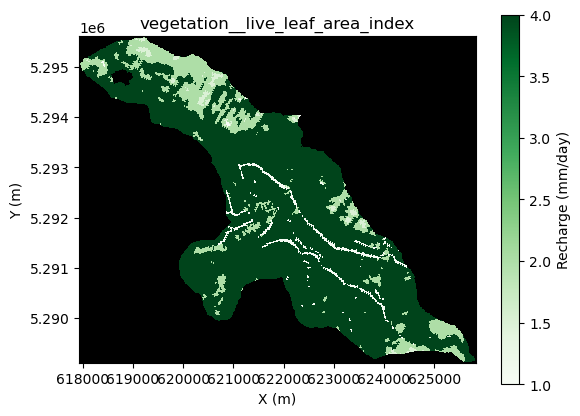

In [35]:
imshow_grid_at_node(grid,'vegetation__live_leaf_area_index', plot_name = 'Maximum Recharge',
            var_name = 'Recharge', var_units = 'mm/day', grid_units = ('m','m'),
            cmap = 'Greens')

In [ ]:
# max_recharge
# routed_recharge_max

array([0., 0., 0., ..., 0., 0., 0.], shape=(513500,))

In [78]:
routed_recharge_max = route_recharge_field(
    grid,
    max_recharge,
    fill_sinks=False,
)
_=grid.add_field('routed_recharge_max', routed_recharge_max, at='node', clobber=True)

_=grid.add_field('groundwater__recharge_mean', routed_recharge_max, at='node', clobber=True)
grid['node']['groundwater__recharge_mean'][grid['node']['groundwater__recharge_mean'] <= 0] = 0.01

_=grid.add_field('groundwater__recharge_standard_deviation', grid.at_node['groundwater__recharge_mean']*0.1, at='node',clobber=True)

_=grid.add_field('groundwater__runoff_mean', max_runoff , at='node', clobber=True)
_=grid.add_field('test_runoff', mean_runoff , at='node', clobber=True)
_=grid.add_field('test_recharge', mean_recharge , at='node', clobber=True)


In [76]:
import numpy as np
import pandas as pd

fields = ["max_recharge", "routed_recharge_max"]

rows = []
for name in fields:
    a = np.asarray(eval(name), dtype=float)[grid.core_nodes]
    a = a[np.isfinite(a)]
    rows.append({
        "field": name,
        "count": a.size,
        "min": np.min(a),
        "p25": np.percentile(a, 25),
        "mean": np.mean(a),
        "median": np.median(a),
        "p75": np.percentile(a, 75),
        "max": np.max(a),
        "std": np.std(a, ddof=1),
    })

pd.DataFrame(rows).set_index("field")


,count,min,p25,mean,median,p75,max,std
field,,,,,,,,
max_recharge,174759,1.096174,5.858201,14.061713,6.923367,9.248834,57.694309,16.011352
routed_recharge_max,174759,1.141030,6.320561,14.841163,7.713984,14.620509,56.996527,14.776196


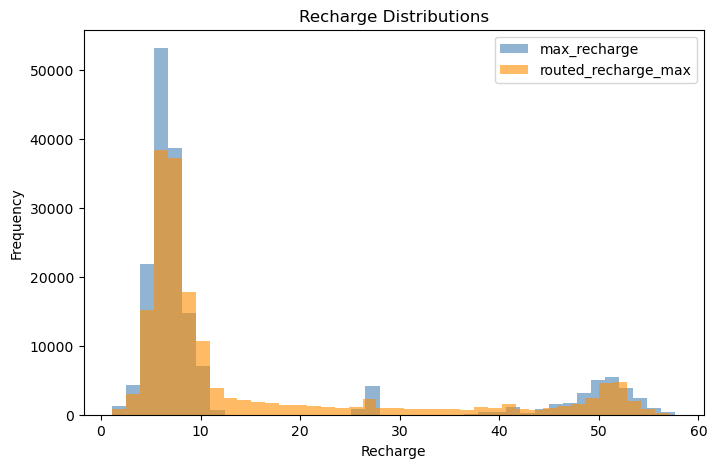

In [77]:
import matplotlib.pyplot as plt

core = grid.core_nodes

plt.figure(figsize=(8,5))
plt.hist(max_recharge[core], bins=40, alpha=0.6, label="max_recharge", color="steelblue")
plt.hist(routed_recharge_max[core], bins=40, alpha=0.6, label="routed_recharge_max", color="darkorange")
plt.xlabel("Recharge")
plt.ylabel("Frequency")
plt.legend()
plt.title("Recharge Distributions")
plt.show()


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from landlab.components.landslides import LandslideProbability

core = grid.core_nodes

def run_ls_scenario(recharge_mean, label, n_iter=1000):
    r = np.asarray(recharge_mean, dtype=float).copy()
    r[~np.isfinite(r)] = 0.01
    r[r <= 0] = 0.01
    rstd = 0.1 * r

    LS_prob = LandslideProbability(
        grid,
        number_of_iterations=n_iter,
        groundwater__recharge_distribution="lognormal_spatial",
        groundwater__recharge_mean=r,
        groundwater__recharge_standard_deviation=rstd,
    )
    LS_prob.calculate_landslide_probability()

    wetness_field = (
        "soil__mean_relative_wetness"
        if "soil__mean_relative_wetness" in grid.at_node
        else "soil_mean_relative_wetness"
    )

    out = {
        "pf": grid.at_node["landslide__probability_of_failure"].copy(),
        "ps": grid.at_node["soil__probability_of_saturation"].copy(),
        "mw": grid.at_node[wetness_field].copy(),
    }

    grid.add_field(f"landslide__probability_of_failure_{label}", out["pf"], at="node", clobber=True)
    grid.add_field(f"soil__probability_of_saturation_{label}", out["ps"], at="node", clobber=True)
    grid.add_field(f"{wetness_field}_{label}", out["mw"], at="node", clobber=True)

    return out

results = {
    "local": run_ls_scenario(max_recharge, "local"),
    "routed": run_ls_scenario(routed_recharge_max, "routed"),
}


/home/abdullah/miniconda3/envs/landlab_debrisflow/lib/python3.11/site-packages/landlab/components/landslides/landslide_probability.py:579: RuntimeWarning: divide by zero encountered in scalar divide
  self._a / np.sin(np.arctan(self._theta))
/home/abdullah/miniconda3/envs/landlab_debrisflow/lib/python3.11/site-packages/landlab/components/landslides/landslide_probability.py:594: RuntimeWarning: divide by zero encountered in divide
  self._FS = (self._C_dim / np.sin(np.arctan(self._theta))) + (
/home/abdullah/miniconda3/envs/landlab_debrisflow/lib/python3.11/site-packages/landlab/components/landslides/landslide_probability.py:595: RuntimeWarning: divide by zero encountered in divide
  np.cos(np.arctan(self._theta)) * (Y / np.sin(np.arctan(self._theta)))


In [85]:
rows = []

selected = ["pf"]          # example: ["pf"] or ["pf", "ps", "mw"]

var_names = {
    "pf": "landslide__probability_of_failure",
    "ps": "soil__probability_of_saturation",
    "mw": "mean_relative_wetness",
}

for scenario, out in results.items():
    for key in selected:
        arr = out[key]
        a = np.asarray(arr, dtype=float)[core]
        a = a[np.isfinite(a)]
        rows.append({
            "scenario": scenario,
            "variable": var_names[key],
            "count": a.size,
            "min": np.min(a),
            "p25": np.percentile(a, 25),
            "mean": np.mean(a),
            "median": np.median(a),
            "p75": np.percentile(a, 75),
            "max": np.max(a),
            "std": np.std(a, ddof=1),
        })

pd.DataFrame(rows)


,scenario,variable,count,min,p25,mean,median,p75,max,std
0,local,landslide__probability_of_failure,174759,0.0,0.0,0.164497,0.009,0.188,1.0,0.283365
1,routed,landslide__probability_of_failure,174759,0.0,0.0,0.169465,0.011,0.207,1.0,0.284127


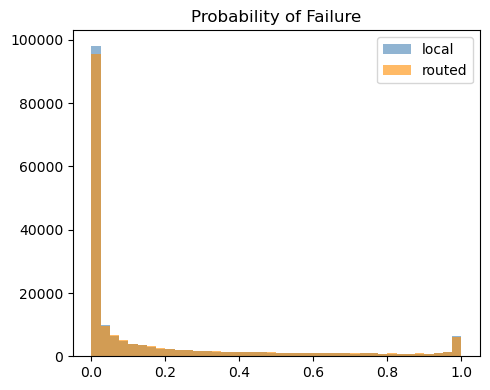

In [86]:
selected = ["pf"]   # example: ["pf"] or ["pf", "ps", "mw"]

titles = {
    "pf": "Probability of Failure",
    "ps": "Probability of Saturation",
    "mw": "Mean Relative Wetness",
}

n = len(selected)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]

for ax, key in zip(axes, selected):
    a_local = np.asarray(results["local"][key], dtype=float)[core]
    a_routed = np.asarray(results["routed"][key], dtype=float)[core]

    a_local = a_local[np.isfinite(a_local)]
    a_routed = a_routed[np.isfinite(a_routed)]

    ax.hist(a_local, bins=40, alpha=0.6, label="local", color="steelblue")
    ax.hist(a_routed, bins=40, alpha=0.6, label="routed", color="darkorange")
    ax.set_title(titles[key])
    ax.legend()

plt.tight_layout()
plt.show()


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from landlab.plot.imshow import imshow_grid_at_node

# choose variable: "pf", "ps", or "mw"
key = "pf"

a_local = np.asarray(results["local"][key], dtype=float)[core]
a_routed = np.asarray(results["routed"][key], dtype=float)[core]

mask = np.isfinite(a_local) & np.isfinite(a_routed)
x = a_local[mask]
y = a_routed[mask]
d = y - x

# summary matrix
summary = pd.DataFrame([{
    "variable": key,
    "n": len(d),
    "local_mean": np.mean(x),
    "routed_mean": np.mean(y),
    "diff_mean": np.mean(d),
    "diff_median": np.median(d),
    "diff_std": np.std(d, ddof=1),
    "diff_min": np.min(d),
    "diff_max": np.max(d),
    "rmse": np.sqrt(np.mean(d**2)),
    "corr": np.corrcoef(x, y)[0,1],
    "r2": np.corrcoef(x, y)[0,1]**2,
}])

summary


,variable,n,local_mean,routed_mean,diff_mean,diff_median,diff_std,diff_min,diff_max,rmse,corr,r2
0,pf,174759,0.164497,0.169465,0.004967,0.0,0.052071,-0.869,0.876,0.052307,0.983165,0.966614


In [ ]:
diff_layer = np.full(grid.number_of_nodes, np.nan)
diff_layer[core] = results["routed"][key][core] - results["local"][key][core]

field_name = f"{key}_routed_minus_local"
grid.add_field(field_name, diff_layer, at="node", clobber=True)

array([nan, nan, nan, ..., nan, nan, nan], shape=(513500,))

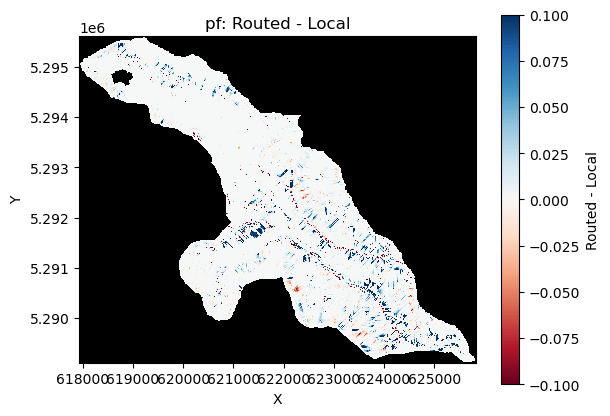

In [ ]:
imshow_grid_at_node(grid, field_name, cmap="RdBu", colorbar_label="Routed - Local")
plt.title(f"{key}: Routed - Local")
plt.show()

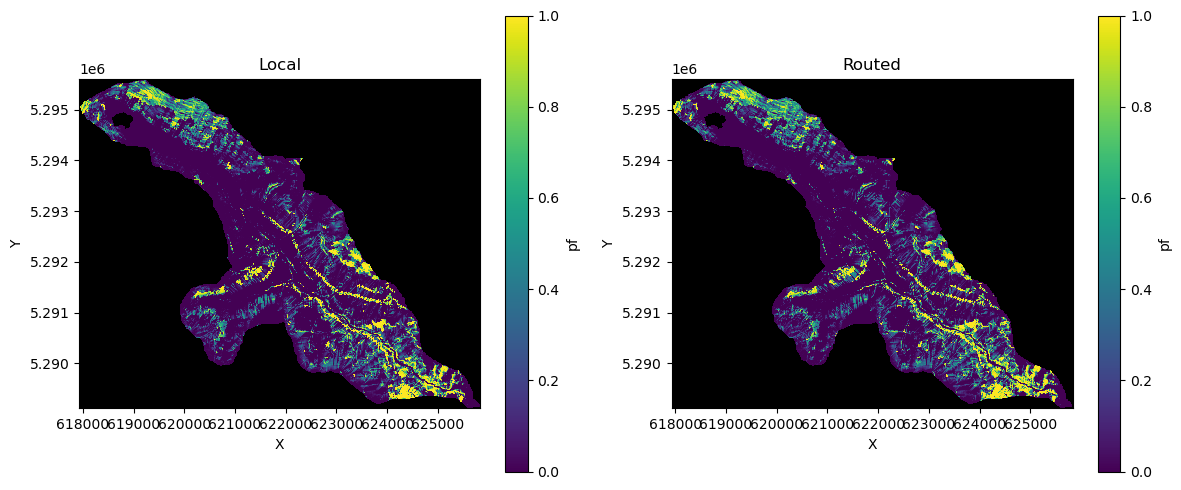

In [91]:
import matplotlib.pyplot as plt
from landlab.plot.imshow import imshow_grid_at_node

key = "pf"  # "pf", "ps", or "mw"

field_local = f"{key}_local_map"
field_routed = f"{key}_routed_map"

grid.add_field(field_local, results["local"][key], at="node", clobber=True)
grid.add_field(field_routed, results["routed"][key], at="node", clobber=True)

vmin = min(np.nanmin(results["local"][key][core]), np.nanmin(results["routed"][key][core]))
vmax = max(np.nanmax(results["local"][key][core]), np.nanmax(results["routed"][key][core]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.sca(axes[0])
imshow_grid_at_node(grid, field_local, cmap="viridis", limits=(vmin, vmax), colorbar_label=key)
plt.title("Local")

plt.sca(axes[1])
imshow_grid_at_node(grid, field_routed, cmap="viridis", limits=(vmin, vmax), colorbar_label=key)
plt.title("Routed")

plt.tight_layout()
plt.show()


### Step 27: Diagnostic Map: Runoff
Visualize spatial runoff summary output to identify hotspots and routing patterns.


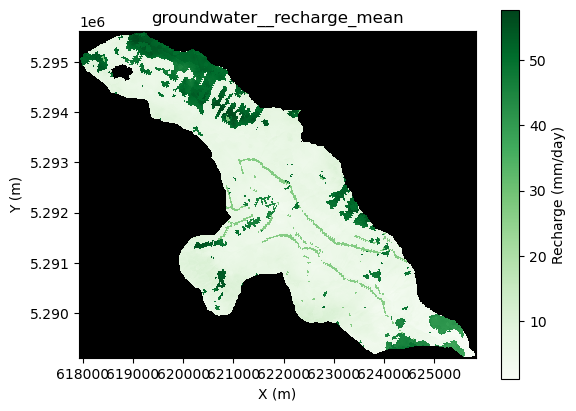

In [65]:
# imshow_grid_at_node(grid,'groundwater__runoff_mean', plot_name = 'Maximum Recharge',
#             var_name = 'Recharge', var_units = 'mm/day', grid_units = ('m','m'),
#             cmap = 'Greens') 

imshow_grid_at_node(grid,'groundwater__recharge_mean', plot_name = 'Maximum Recharge',
            var_name = 'Recharge', var_units = 'mm/day', grid_units = ('m','m'),
            cmap = 'Greens')

# imshow_grid_at_node(grid,'test_recharge', plot_name = 'Maximum Recharge',
#             var_name = 'Recharge', var_units = 'mm/day', grid_units = ('m','m'),
#             cmap = 'Greens')

### Step 28: Route Maximum Recharge and Run Monte Carlo
Route the maximum local recharge field with D8 flow accumulation to compute an upslope-area-averaged recharge field, then use that routed recharge in `LandslideProbability`.


In [74]:
recharge_for_ls = grid.at_node['groundwater__recharge_mean']
recharge_std_for_ls = grid.at_node['groundwater__recharge_standard_deviation']

recharge_for_ls

array([0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01], shape=(513500,))

In [66]:
recharge_for_ls = grid.at_node['groundwater__recharge_mean']
recharge_std_for_ls = grid.at_node['groundwater__recharge_standard_deviation']

#C_mode = post_fire_cohesion(t, grid.at_node['soil__mode_total_cohesion_pre'], grid.at_node['burn__severity'])
#C_min = post_fire_cohesion(t, grid.at_node['soil__minimum_total_cohesion_pre'], grid.at_node['burn__severity'])
#C_max = post_fire_cohesion(t, grid.at_node['soil__maximum_total_cohesion_pre'], grid.at_node['burn__severity'])

number_of_iterations = 1000

LS_prob = LandslideProbability(
    grid,
    number_of_iterations=number_of_iterations,
    groundwater__recharge_distribution='lognormal_spatial',
    groundwater__recharge_mean=recharge_for_ls,
    groundwater__recharge_standard_deviation=recharge_std_for_ls,
)

LS_prob.calculate_landslide_probability()

print('run done')

run done


### Step 31: Summarize Landslide Outputs
List generated landslide/saturation fields and print core-node statistics for probability of failure and wetness diagnostics.


In [40]:
pip install rasterio

  Using cached rasterio-1.4.4-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (9.3 kB)
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
Using cached rasterio-1.4.4-cp311-cp311-manylinux_2_28_x86_64.whl (35.9 MB)
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached affine-2.4.0-py3-none-any.whl (15 kB)
Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [rasterio]3/4 [rasterio]
Note: you may need to restart the kernel to use updated packages.


In [67]:
# 1) See what landslide outputs were created
print([k for k in grid.at_node.keys() if "landslide" in k or "saturation" in k or "wetness" in k])

# 2) Quick stats on core nodes
core = grid.core_nodes
pf = grid.at_node["landslide__probability_of_failure"]
ps = grid.at_node["soil__probability_of_saturation"]
mw = grid.at_node["soil__mean_relative_wetness"]

print("Pf mean/min/max:", pf[core].mean(), pf[core].min(), pf[core].max())
print("Ps mean/min/max:", ps[core].mean(), ps[core].min(), ps[core].max())
print("Wetness mean/min/max:", mw[core].mean(), mw[core].min(), mw[core].max())

['soil_moisture__initial_saturation_fraction', 'soil__mean_relative_wetness', 'landslide__probability_of_failure', 'soil__probability_of_saturation']
Pf mean/min/max: 0.16449747375277446 0.0 1.0
Ps mean/min/max: 0.3949167940909683 0.0 1.0
Wetness mean/min/max: 0.6014006250902338 0.0057156253884087125 1.0


In [41]:
from pathlib import Path
import numpy as np
import rasterio

out_dir = Path("/mnt/c/Users/amehedi/Downloads/eagle")
out_dir.mkdir(parents=True, exist_ok=True)

fields = [
    "landslide__probability_of_failure",
    "soil__probability_of_saturation",
    "soil_mean_relative_wetness",
]

template = Path("/home/abdullah/fire-debrisflow-ml/data/topographic__elevation.asc")

with rasterio.open(template) as src:
    meta_template = src.meta.copy()
    dem_template = src.read(1)
    dem_nodata = src.nodata

nrows, ncols = grid.shape
topo_grid = grid.at_node["topographic__elevation"].reshape((nrows, ncols))

valid = np.isfinite(dem_template)
if dem_nodata is not None:
    valid &= ~np.isclose(dem_template, dem_nodata)

err_same = np.nanmean(np.abs(topo_grid[valid] - dem_template[valid]))
err_flip = np.nanmean(np.abs(np.flipud(topo_grid)[valid] - dem_template[valid]))
flip_needed = err_flip < err_same
print("flip_needed:", flip_needed)

closed = (grid.status_at_node == grid.BC_NODE_IS_CLOSED).reshape((nrows, ncols))
if flip_needed:
    closed = np.flipud(closed)

for f in fields:
    if f not in grid.at_node:
        print("skip:", f)
        continue

    arr = grid.at_node[f].reshape((nrows, ncols)).astype(np.float32)
    if flip_needed:
        arr = np.flipud(arr)

    nodata = np.float32(-9999.0)
    arr_out = np.where(np.isfinite(arr) & (~closed), arr, nodata).astype(np.float32)

    # TIF
    meta_tif = meta_template.copy()
    meta_tif.update(
        driver="GTiff",
        dtype="float32",
        count=1,
        nodata=nodata,
        compress="lzw",
        crs="EPSG:32610",
    )
    with rasterio.open(out_dir / f"{f}.tif", "w", **meta_tif) as dst:
        dst.write(arr_out, 1)

    # ASC
    meta_asc = meta_template.copy()
    meta_asc.update(
        driver="AAIGrid",
        dtype="float32",
        count=1,
        nodata=nodata,
        crs="EPSG:32610",
    )
    with rasterio.open(out_dir / f"{f}.asc", "w", **meta_asc) as dst:
        dst.write(arr_out, 1)

    print("saved:", out_dir / f"{f}.tif")
    print("saved:", out_dir / f"{f}.asc")

flip_needed: True
saved: /mnt/c/Users/amehedi/Downloads/eagle/landslide__probability_of_failure.tif
saved: /mnt/c/Users/amehedi/Downloads/eagle/landslide__probability_of_failure.asc
saved: /mnt/c/Users/amehedi/Downloads/eagle/soil__probability_of_saturation.tif
saved: /mnt/c/Users/amehedi/Downloads/eagle/soil__probability_of_saturation.asc
skip: soil_mean_relative_wetness


### Step 32: Plot Final Landslide Metrics
Map probability of failure, probability of saturation, and mean relative wetness to communicate spatial hazard outcomes.


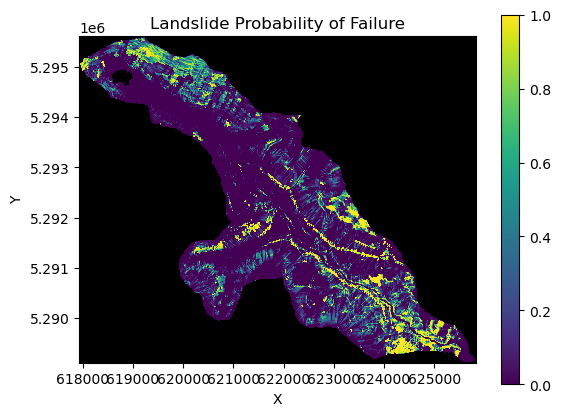

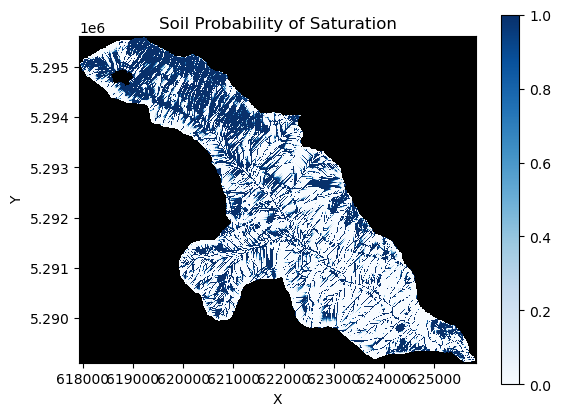

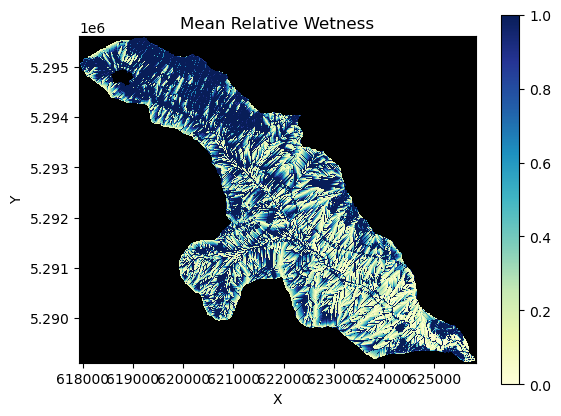

In [68]:
# 3) Plot maps
imshow_grid_at_node(grid, "landslide__probability_of_failure", cmap="viridis", limits=(0,1))
plt.title("Landslide Probability of Failure")
plt.show()

imshow_grid_at_node(grid, "soil__probability_of_saturation", cmap="Blues", limits=(0,1))
plt.title("Soil Probability of Saturation")
plt.show()

imshow_grid_at_node(grid, "soil__mean_relative_wetness", cmap="YlGnBu", limits=(0,1))
plt.title("Mean Relative Wetness")
plt.show()

### Step 33: Plot Daily Flux Time Series
Aggregate daily core-node recharge/runoff and plot time series for event-scale hydrologic interpretation.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

# --- Example inputs ---
core_nodes = grid.core_nodes

# Compute daily means
daily_mean_recharge = np.array([np.mean(arr[core_nodes]) for arr in recharge_arrays])
daily_mean_runoff   = np.array([np.mean(arr[core_nodes]) for arr in runoff_arrays])

# Dates for x-axis
dates = pd.date_range("2025-03-01", "2025-03-31")  # 7 days

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(dates, daily_mean_recharge, '-o', color='black', label="Recharge")
ax.plot(dates, daily_mean_runoff, '-o', color='gray', label="Runoff")

ax.set_xlabel("Date")
ax.set_ylabel("Flux (mm/day)")
ax.set_title("Daily Mean Recharge & Runoff")

# Styling
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()